# Machine Learning Credit Risk Model
## Part 3: Model Development


**Dataset:** LendingClub Loan Data (`accepted_2007_to_2018Q4.csv.gz`)  
**Objective:** Identify, train, and evaluate at least three machine learning models — including at least one supervised and one unsupervised — to predict loan default and segment borrower risk profiles.

---

## Table of Contents
1. Project Overview
2. Import Libraries
3. Data Preparation
4. Feature Encoding
5. Train / Test Split
6. Feature Scaling
7. Dimensionality Reduction — PCA
8. Class Imbalance Assessment
9. MODEL 1 — Logistic Regression (Supervised)
10. MODEL 2 — Random Forest (Supervised)
11. MODEL 3 — XGBoost (Supervised)
12. MODEL 4 — K-Means Clustering (Unsupervised)
13. Model Comparison Summary

---
## 1. Project Overview

### Business Context
This notebook trains and evaluates machine learning models designed to support two distinct business goals:

**Supervised Learning Goal (Models 1–3):** Predict whether a borrower will default on a loan (binary classification: 0 = Fully Paid, 1 = Charged Off). Accurate default predictions allow lenders to improve underwriting decisions, set appropriate interest rates, and reduce expected credit losses.

**Unsupervised Learning Goal (Model 4):** Segment the borrower population into distinct risk clusters based on shared financial characteristics. These clusters can inform portfolio management, targeted product design, and differentiated pricing strategies — even without a labeled outcome variable.

### Models Selected
| # | Model | Type | Rationale |
|---|-------|------|-----------|
| 1 | Logistic Regression | Supervised | Interpretable baseline; coefficients directly indicate feature impact |
| 2 | Random Forest | Supervised | Captures nonlinear relationships; robust to outliers and noise |
| 3 | XGBoost | Supervised | State-of-the-art gradient boosting; typically highest predictive accuracy |
| 4 | K-Means Clustering | Unsupervised | Groups borrowers by financial profile without using default label |

### Workflow Summary
1. Load and prepare the LendingClub dataset (self-contained pipeline)
2. Encode categorical features and define the modeling feature set
3. Split into training and test sets (80/20, stratified)
4. Scale features using StandardScaler
5. Apply PCA for dimensionality reduction analysis
6. Train and evaluate each model with documented hyperparameters
7. Compare models on consistent metrics (Accuracy, Precision, Recall, F1, AUC-ROC)

---
## 2. Import Libraries

In [ ]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================
# This section loads all libraries needed for Part 3.
# Libraries are grouped by purpose for clarity.
#
# To install any missing library from a terminal:
#   pip install pandas numpy matplotlib seaborn scikit-learn xgboost
# ============================================================

# --- Core data manipulation ---
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# --- Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')
pd.set_option('display.max_columns', None)

# --- Preprocessing & splitting ---
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- Dimensionality reduction ---
from sklearn.decomposition import PCA

# --- Evaluation metrics ---
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

# --- Supervised models ---
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# XGBoost — install with: pip install xgboost
try:
    import xgboost as xgb
    print('XGBoost version:', xgb.__version__)
except ImportError:
    raise ImportError('XGBoost not found. Run: pip install xgboost')

# --- Unsupervised model ---
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# --- Reproducibility ---
# Setting a global random seed ensures that any stochastic operation
# (e.g., train/test splits, model initialization) produces the same
# result each time the notebook is run.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('All libraries loaded successfully.')

XGBoost version: 3.2.0
All libraries loaded successfully.


---
## 3. Data Preparation

All data preparation steps are implemented here in a single, self-contained pipeline. This notebook is fully independent and can be run without executing any prior notebook.

Steps performed:
1. Load 200,000 rows of the compressed LendingClub dataset
2. Select nine relevant variables
3. Filter to only final loan outcomes (Fully Paid / Charged Off)
4. Create binary `default` target variable
5. Convert `int_rate` (string) and `term` (string) to numeric
6. Impute missing values (median for numerics, 'Unknown' for categoricals)
7. Engineer `loan_to_income` and `high_dti_flag` features
8. Apply log transformations to `loan_amnt` and `annual_inc`



In [ ]:
# ============================================================
# STEP 3.1 — LOAD DATASET
# ============================================================
# The LendingClub dataset is stored in compressed CSV format (.gz).
# We load 200,000 rows — sufficient to capture meaningful patterns
# while keeping memory usage manageable.
#
# ============================================================

FILE_PATH = 'accepted_2007_to_2018Q4.csv.gz'

df = pd.read_csv(
    FILE_PATH,
    compression='gzip',
    nrows=200000,
    low_memory=False
)

print('Dataset loaded successfully.')
print('Raw shape:', df.shape)

Dataset loaded successfully.
Raw shape: (200000, 151)


In [ ]:
# ============================================================
# STEP 3.2 — SELECT VARIABLES AND DEFINE TARGET
# ============================================================
# Retain only the variables relevant to credit risk analysis.
# Filter to loans with final outcomes and create the binary target variable.
#
# default = 1 → Charged Off (the borrower did not repay)
# default = 0 → Fully Paid (the borrower repaid in full)
# ============================================================

selected_cols = [
    'loan_amnt',
    'int_rate',
    'annual_inc',
    'dti',
    'fico_range_high',
    'term',
    'emp_length',
    'home_ownership',
    'loan_status'
]

df = df[selected_cols]

# Keep only loans with definitive outcomes
df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])].copy()

# Create binary target
df['default'] = np.where(df['loan_status'] == 'Charged Off', 1, 0)

print('Shape after filtering to final outcomes:', df.shape)
print()
print('Target variable distribution:')
print(df['default'].value_counts())
print()
print('Default rate: {:.1f}%'.format(df['default'].mean() * 100))

Shape after filtering to final outcomes: (176082, 10)

Target variable distribution:
default
0    140992
1     35090
Name: count, dtype: int64

Default rate: 19.9%


In [ ]:
# ============================================================
# STEP 3.3 — CLEAN VARIABLE FORMATS
# ============================================================
# int_rate: already numeric in this dataset (float64)
# term: stored as '36 months' or '60 months' — extract the
#       numeric portion and convert to integer
# ============================================================

print('Data types before cleaning:')
print(df[['int_rate', 'term']].dtypes)
print()

# Clean int_rate — handle both string and numeric formats
if df['int_rate'].dtype == object:
    df['int_rate'] = df['int_rate'].str.replace('%', '', regex=False)
df['int_rate'] = pd.to_numeric(df['int_rate'], errors='coerce')

# Clean term — extract the leading number from '36 months'
if df['term'].dtype == object:
    df['term'] = df['term'].str.strip().str.split(' ').str[0]
df['term'] = pd.to_numeric(df['term'], errors='coerce')

print('Data types after cleaning:')
print(df[['int_rate', 'term']].dtypes)
print()
print('Sample values:')
print(df[['int_rate', 'term']].head())

Data types before cleaning:
int_rate    float64
term         object
dtype: object

Data types after cleaning:
int_rate    float64
term          int64
dtype: object

Sample values:
   int_rate  term
0     13.99    36
1     11.99    36
2     10.78    60
4     22.45    60
5     13.44    36


In [ ]:
# ============================================================
# STEP 3.4 — HANDLE MISSING DATA
# ============================================================
# Imputation strategy:
#   - Numeric variables: fill with median to avoid skew influence
#   - Categorical variables: fill with 'Unknown' to preserve rows
# ============================================================

print('Missing values before imputation:')
print(df.isnull().sum()[df.isnull().sum() > 0])
print()

df['annual_inc']      = df['annual_inc'].fillna(df['annual_inc'].median())
df['dti']             = df['dti'].fillna(df['dti'].median())
df['fico_range_high'] = df['fico_range_high'].fillna(df['fico_range_high'].median())
df['emp_length']      = df['emp_length'].fillna('Unknown')
df['home_ownership']  = df['home_ownership'].fillna('Unknown')

print('Missing values after imputation:')
print(df.isnull().sum())

Missing values before imputation:
dti               2
emp_length    11134
dtype: int64

Missing values after imputation:
loan_amnt          0
int_rate           0
annual_inc         0
dti                0
fico_range_high    0
term               0
emp_length         0
home_ownership     0
loan_status        0
default            0
dtype: int64


In [ ]:
# ============================================================
# STEP 3.5 — FEATURE ENGINEERING & TRANSFORMATIONS
# ============================================================
# New features created:
#
# loan_to_income : loan_amnt / annual_inc
#   Captures leverage — how large the loan is relative to income.
#   A high ratio indicates the borrower is stretching financially.
#
# high_dti_flag  : 1 if DTI > 20, else 0
#   Binary flag for elevated debt burden. DTI > 20 was identified
#   threshold associated with higher default rates.
#
# log_loan_amnt  : log1p(loan_amnt)
# log_annual_inc : log1p(annual_inc)
#   Log transformations reduce right-skewness in financial variables,
#   improving model convergence and performance for linear models.
# ============================================================

# Guard against zero income before division
df['annual_inc'] = df['annual_inc'].replace(0, np.nan)
df['annual_inc'] = df['annual_inc'].fillna(df['annual_inc'].median())

df['loan_to_income'] = df['loan_amnt'] / df['annual_inc']
df['high_dti_flag']  = np.where(df['dti'] > 20, 1, 0)
df['log_loan_amnt']  = np.log1p(df['loan_amnt'])
df['log_annual_inc'] = np.log1p(df['annual_inc'])

print('Feature engineering complete. Dataset shape:', df.shape)
print()
print('New columns added:')
print(df[['loan_to_income', 'high_dti_flag', 'log_loan_amnt', 'log_annual_inc']].head())

Feature engineering complete. Dataset shape: (176082, 14)

New columns added:
   loan_to_income  high_dti_flag  log_loan_amnt  log_annual_inc
0        0.065455              0       8.188967       10.915107
1        0.380000              0      10.114599       11.082158
2        0.317460              0       9.903538       11.050906
4        0.099585              1       9.249657       11.556311
5        0.351471              0       9.388570       10.434145


---
## 4. Feature Encoding

Machine learning models require numeric inputs. Two categorical variables need to be encoded:

**`emp_length` — Ordinal Encoding**  
Employment length has a natural order (< 1 year < 1 year < 2 years < ... < 10+ years). We map each category to a numeric value (0–10) that preserves this ordering. 'Unknown' values are assigned the midpoint value of 5, which is consistent with our median-imputation approach used for other missing data.

**`home_ownership` — One-Hot Encoding**  
Home ownership categories (RENT, OWN, MORTGAGE, OTHER) have no natural ordering, so I use one-hot encoding. This creates a separate binary column for each category. To avoid multicollinearity (the dummy variable trap), I drop one reference category (OTHER/NONE) when building the feature matrix.

In [ ]:
# ============================================================
# STEP 4.1 — ENCODE emp_length (ORDINAL)
# ============================================================
# Employment length is ordinal: longer tenure generally correlates
# with greater job stability, which may reduce default risk.
# We assign integers 0–10, with 'Unknown' mapped to 5 (midpoint).
# ============================================================

emp_length_map = {
    '< 1 year': 0,
    '1 year':   1,
    '2 years':  2,
    '3 years':  3,
    '4 years':  4,
    '5 years':  5,
    '6 years':  6,
    '7 years':  7,
    '8 years':  8,
    '9 years':  9,
    '10+ years': 10,
    'Unknown':   5   # Impute with midpoint (neutral assumption)
}

df['emp_length_num'] = df['emp_length'].map(emp_length_map)

# Verify no nulls after mapping
unmapped = df['emp_length_num'].isnull().sum()
if unmapped > 0:
    print(f'WARNING: {unmapped} rows could not be mapped. Check unique values below.')
    print(df['emp_length'].unique())
else:
    print('emp_length_num: all values mapped successfully.')

print()
print('Mapping summary:')
print(df.groupby('emp_length')['emp_length_num'].first().sort_values())

emp_length_num: all values mapped successfully.

Mapping summary:
emp_length
< 1 year      0
1 year        1
2 years       2
3 years       3
4 years       4
5 years       5
Unknown       5
6 years       6
7 years       7
8 years       8
9 years       9
10+ years    10
Name: emp_length_num, dtype: int64


In [ ]:
# ============================================================
# STEP 4.2 — ENCODE home_ownership (ONE-HOT)
# ============================================================
# home_ownership has no natural ordering, so one-hot encoding
# is appropriate. We create binary dummy columns for MORTGAGE,
# OWN, and RENT. The remaining categories (OTHER, NONE, ANY)
# serve as the implicit reference group.
# ============================================================

print('home_ownership value counts before encoding:')
print(df['home_ownership'].value_counts())
print()

home_dummies = pd.get_dummies(
    df['home_ownership'],
    prefix='home'
)

# Keep only the three main categories to avoid noise from rare values
keep_cols = ['home_MORTGAGE', 'home_OWN', 'home_RENT']
home_dummies = home_dummies[[c for c in keep_cols if c in home_dummies.columns]]

df = pd.concat([df, home_dummies], axis=1)

print('One-hot encoded columns added:')
print(home_dummies.head())

home_ownership value counts before encoding:
home_ownership
MORTGAGE    86297
RENT        69952
OWN         19832
ANY             1
Name: count, dtype: int64

One-hot encoded columns added:
   home_MORTGAGE  home_OWN  home_RENT
0           True     False      False
1           True     False      False
2           True     False      False
4           True     False      False
5          False     False       True


In [ ]:
# ============================================================
# STEP 4.3 — DEFINE FEATURE SET AND TARGET
# ============================================================
# Feature set rationale:
#
# Raw numeric features:
#   loan_amnt       — size of the loan request
#   int_rate        — risk-based price assigned by lender
#   dti             — borrower debt load relative to income
#   fico_range_high — creditworthiness proxy
#   term            — loan duration (36 or 60 months)
#
# Engineered features:
#   loan_to_income  — leverage ratio
#   high_dti_flag   — binary flag for elevated debt burden
#   log_loan_amnt   — log-transformed loan amount (reduces skew)
#   log_annual_inc  — log-transformed income (reduces skew)
#
# Encoded categorical features:
#   emp_length_num  — ordinal employment length
#   home_MORTGAGE   — binary: borrower has a mortgage
#   home_OWN        — binary: borrower owns home outright
#   home_RENT       — binary: borrower rents
#
# Note: annual_inc is excluded from the feature set because
# it is already captured via log_annual_inc and loan_to_income,
# and its raw scale would dominate distance-based models.
# ============================================================

FEATURE_COLS = [
    'loan_amnt',
    'int_rate',
    'dti',
    'fico_range_high',
    'term',
    'loan_to_income',
    'high_dti_flag',
    'log_loan_amnt',
    'log_annual_inc',
    'emp_length_num',
    'home_MORTGAGE',
    'home_OWN',
    'home_RENT'
]

TARGET_COL = 'default'

# Verify all feature columns exist
missing_cols = [c for c in FEATURE_COLS if c not in df.columns]
if missing_cols:
    raise ValueError(f'Missing columns: {missing_cols}')

X = df[FEATURE_COLS].copy()
y = df[TARGET_COL].copy()

print('Feature matrix shape:', X.shape)
print('Target vector shape: ', y.shape)
print()
print('Feature columns:')
for i, col in enumerate(FEATURE_COLS, 1):
    print(f'  {i:2d}. {col}')

Feature matrix shape: (176082, 13)
Target vector shape:  (176082,)

Feature columns:
   1. loan_amnt
   2. int_rate
   3. dti
   4. fico_range_high
   5. term
   6. loan_to_income
   7. high_dti_flag
   8. log_loan_amnt
   9. log_annual_inc
  10. emp_length_num
  11. home_MORTGAGE
  12. home_OWN
  13. home_RENT


---
## 5. Train / Test Split

We split the data into an 80% training set and a 20% test set.

**Why 80/20?** With ~176,000 observations, an 80/20 split gives us ~141,000 training samples (sufficient for complex models) and ~35,000 test samples (sufficient for reliable metric estimation).

**Why stratify?** The dataset is imbalanced (~80% non-default, ~20% default). The `stratify=y` parameter ensures both splits maintain this same ratio, so the test set is representative and evaluation metrics are not inflated.

**Critical rule:** The test set is held completely separate until final evaluation. All preprocessing (scaling, PCA) is fit on training data only and then applied to test data. This prevents data leakage.

In [ ]:
# ============================================================
# STEP 5 — TRAIN / TEST SPLIT
# ============================================================
# test_size   = 0.20 → 20% held out for final evaluation
# stratify    = y    → preserves default rate in both splits
# random_state = 42  → ensures reproducibility
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print('Training set  :', X_train.shape, '|', 'Default rate: {:.1f}%'.format(y_train.mean() * 100))
print('Test set      :', X_test.shape,  '|', 'Default rate: {:.1f}%'.format(y_test.mean() * 100))
print()
print('Stratification check — default counts:')
print('  Train:', y_train.value_counts().to_dict())
print('  Test: ', y_test.value_counts().to_dict())

Training set  : (140865, 13) | Default rate: 19.9%
Test set      : (35217, 13) | Default rate: 19.9%

Stratification check — default counts:
  Train: {0: 112793, 1: 28072}
  Test:  {0: 28199, 1: 7018}


---
## 6. Feature Scaling

**Why scale?** Features in our dataset have very different magnitudes — `loan_amnt` ranges from $1,000 to $35,000 while `high_dti_flag` is 0 or 1. Without scaling:
- Logistic Regression converges slowly or fails to converge
- PCA (next step) is dominated by high-variance features
- Distance-based methods (K-Means) produce distorted clusters

**StandardScaler** transforms each feature to zero mean and unit standard deviation:  
`z = (x - mean) / std`

**Data leakage prevention:** The scaler is fit on the **training set only**. The same training-set statistics (mean, std) are then applied to the test set. Fitting the scaler on the full dataset would allow test-set information to influence training, producing optimistically biased metrics.

In [ ]:
# ============================================================
# STEP 6 — FEATURE SCALING (StandardScaler)
# ============================================================
# fit()       — compute mean and std from TRAINING data only
# transform() — apply those statistics to both train and test
# ============================================================

scaler = StandardScaler()

# Fit on training data only
X_train_scaled = scaler.fit_transform(X_train)

# Apply (do NOT re-fit) on test data
X_test_scaled  = scaler.transform(X_test)

print('Scaling complete.')
print()
print('Training set — mean after scaling (should be ~0):')
print(pd.Series(X_train_scaled.mean(axis=0), index=FEATURE_COLS).round(4))
print()
print('Training set — std after scaling (should be ~1):')
print(pd.Series(X_train_scaled.std(axis=0), index=FEATURE_COLS).round(4))

Scaling complete.

Training set — mean after scaling (should be ~0):
loan_amnt         -0.0
int_rate          -0.0
dti               -0.0
fico_range_high    0.0
term               0.0
loan_to_income    -0.0
high_dti_flag      0.0
log_loan_amnt     -0.0
log_annual_inc    -0.0
emp_length_num     0.0
home_MORTGAGE     -0.0
home_OWN           0.0
home_RENT         -0.0
dtype: float64

Training set — std after scaling (should be ~1):
loan_amnt          1.0
int_rate           1.0
dti                1.0
fico_range_high    1.0
term               1.0
loan_to_income     1.0
high_dti_flag      1.0
log_loan_amnt      1.0
log_annual_inc     1.0
emp_length_num     1.0
home_MORTGAGE      1.0
home_OWN           1.0
home_RENT          1.0
dtype: float64


---
## 7. Dimensionality Reduction — PCA

**Principal Component Analysis (PCA)** finds the directions of maximum variance in the feature space and projects the data onto a lower-dimensional subspace. This serves two purposes in our project:

1. **Understanding feature structure:** The scree plot reveals how much of the total variance is explained by each component. If 90% of variance is captured in far fewer dimensions than the original 13 features, the data has significant structure that PCA can exploit.

2. **Alternative feature set for supervised models:** We will train Logistic Regression on PCA-reduced features and compare AUC vs. the original feature set — demonstrating whether compression helps or hurts performance.

3. **Required input for K-Means:** K-Means is sensitive to the curse of dimensionality. Reducing to a compact PCA representation (typically 2–5 components) improves cluster quality and enables 2D visualization.

PCA is fit on **scaled training data only** (same data-leakage prevention principle as the scaler).

In [ ]:
# ============================================================
# STEP 7.1 — FIT PCA AND INSPECT VARIANCE EXPLAINED
# ============================================================
# I fit PCA retaining all 13 components first to examine
# the full variance explained curve before deciding how many
# components to keep.
# ============================================================

n_features = X_train_scaled.shape[1]

pca_full = PCA(n_components=n_features, random_state=RANDOM_STATE)
pca_full.fit(X_train_scaled)

explained_variance        = pca_full.explained_variance_ratio_
cumulative_variance       = np.cumsum(explained_variance)

print('Variance explained by each principal component:')
print()
print('{:<6} {:<20} {:<25}'.format('PC', 'Explained Variance', 'Cumulative Variance'))
print('-' * 52)
for i, (ev, cv) in enumerate(zip(explained_variance, cumulative_variance), 1):
    print('{:<6} {:<20.4f} {:<25.4f}'.format(i, ev, cv))

Variance explained by each principal component:

PC     Explained Variance   Cumulative Variance      
----------------------------------------------------
1      0.2277               0.2277                   
2      0.1840               0.4117                   
3      0.1326               0.5443                   
4      0.1031               0.6475                   
5      0.0920               0.7395                   
6      0.0764               0.8159                   
7      0.0679               0.8838                   
8      0.0590               0.9429                   
9      0.0298               0.9727                   
10     0.0174               0.9900                   
11     0.0054               0.9954                   
12     0.0046               1.0000                   
13     0.0000               1.0000                   


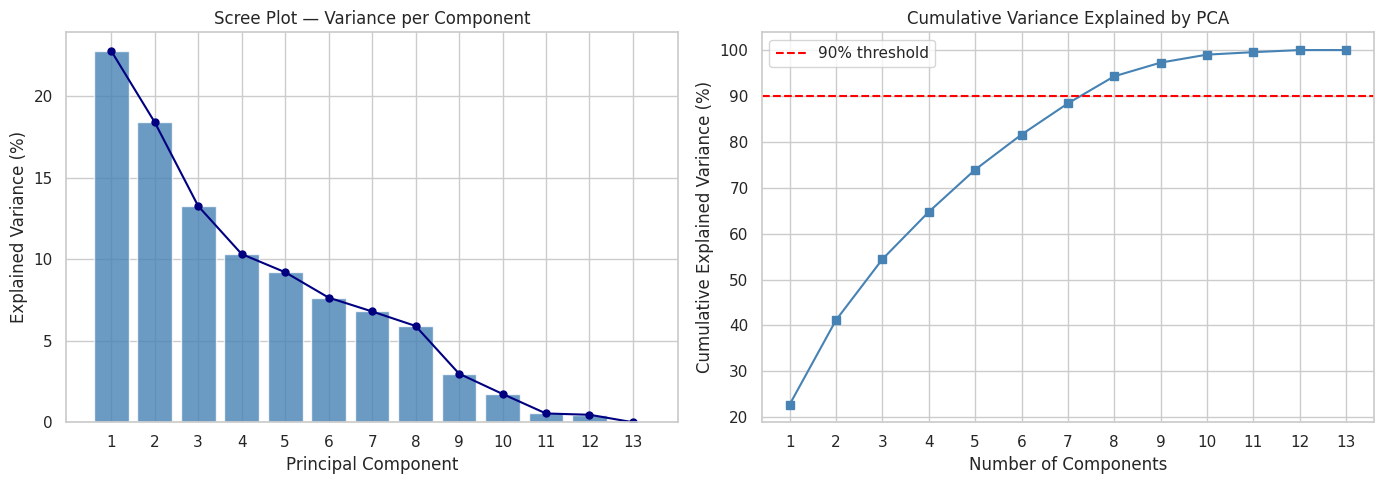

Components needed to explain 90% of variance: 8
Variance explained by 8 components: 94.29%


In [ ]:
# ============================================================
# STEP 7.2 — SCREE PLOT AND CUMULATIVE VARIANCE PLOT
# ============================================================
# The scree plot shows the marginal variance added by each
# additional component. The 'elbow' in this curve indicates
# where additional components contribute diminishing returns.
#
# The cumulative variance plot shows the total information
# retained as more components are included. A horizontal
# line at 90% to identify the minimum number of components
# needed to preserve most of the variance.
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

components = range(1, n_features + 1)

# --- Scree plot ---
axes[0].bar(components, explained_variance * 100, color='steelblue', alpha=0.8)
axes[0].plot(components, explained_variance * 100, 'o-', color='navy', markersize=5)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('Scree Plot — Variance per Component')
axes[0].set_xticks(list(components))

# --- Cumulative variance plot ---
axes[1].plot(components, cumulative_variance * 100, 's-', color='steelblue', markersize=6)
axes[1].axhline(y=90, color='red', linestyle='--', label='90% threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance (%)')
axes[1].set_title('Cumulative Variance Explained by PCA')
axes[1].set_xticks(list(components))
axes[1].legend()

plt.tight_layout()
plt.show()

# Determine components needed for 90% variance
n_components_90 = int(np.argmax(cumulative_variance >= 0.90)) + 1
print(f'Components needed to explain 90% of variance: {n_components_90}')
print(f'Variance explained by {n_components_90} components: {cumulative_variance[n_components_90-1]*100:.2f}%')

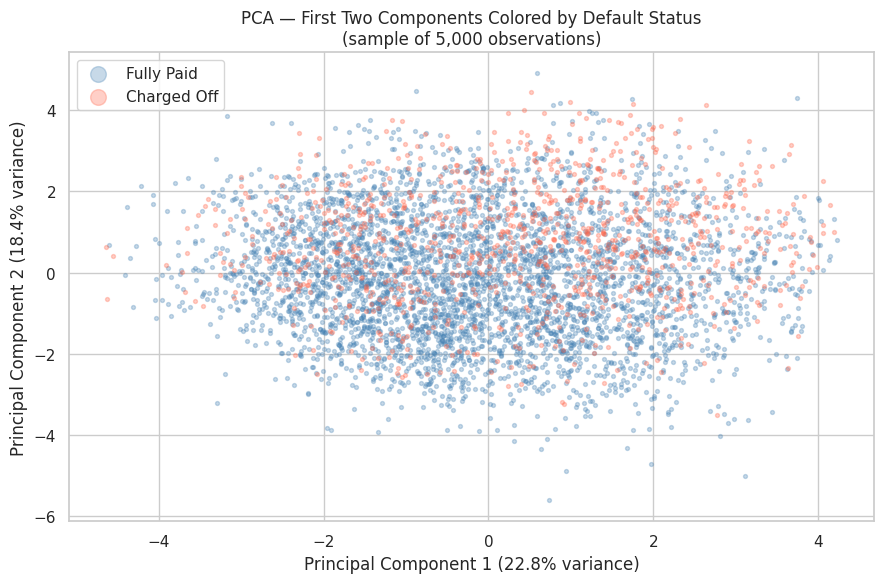

Total variance explained by first 2 PCs: 41.17%


In [ ]:
# ============================================================
# STEP 7.3 — 2D PCA SCATTER PLOT
# ============================================================
# Projecting data onto the first two principal components gives
# us the best possible 2D representation of the dataset.
# Color-coding by default status shows whether PC1 and PC2
# provide visual separation between the two classes.
#
# Note: We use a random sample of 5,000 points for visibility.
# ============================================================

pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_2d = pca_2d.fit_transform(X_train_scaled)

# Sample for plotting
sample_idx = np.random.choice(len(X_train_2d), size=5000, replace=False)
X_plot     = X_train_2d[sample_idx]
y_plot     = y_train.values[sample_idx]

plt.figure(figsize=(9, 6))
for label, color, name in [(0, 'steelblue', 'Fully Paid'), (1, 'tomato', 'Charged Off')]:
    mask = y_plot == label
    plt.scatter(
        X_plot[mask, 0], X_plot[mask, 1],
        c=color, alpha=0.3, s=8, label=name
    )

plt.xlabel('Principal Component 1 ({:.1f}% variance)'.format(
    pca_2d.explained_variance_ratio_[0] * 100))
plt.ylabel('Principal Component 2 ({:.1f}% variance)'.format(
    pca_2d.explained_variance_ratio_[1] * 100))
plt.title('PCA — First Two Components Colored by Default Status\n(sample of 5,000 observations)')
plt.legend(markerscale=4)
plt.tight_layout()
plt.show()

total_2d = (pca_2d.explained_variance_ratio_.sum() * 100)
print(f'Total variance explained by first 2 PCs: {total_2d:.2f}%')

In [ ]:
# ============================================================
# STEP 7.4 — CREATE PCA-REDUCED FEATURE ARRAYS
# ============================================================
# We create two PCA versions for downstream use:
#   X_train_pca / X_test_pca  : n_components_90 dimensions
#     → used as an alternative input for supervised models
#       to see whether dimensionality reduction improves AUC
#   X_pca_4d                  : 4 components
#     → used as input for K-Means (compact, noise-reduced)
# ============================================================

# PCA retaining 90% of variance
pca_90 = PCA(n_components=n_components_90, random_state=RANDOM_STATE)
X_train_pca = pca_90.fit_transform(X_train_scaled)
X_test_pca  = pca_90.transform(X_test_scaled)

print(f'PCA (90% variance) — training set shape: {X_train_pca.shape}')
print(f'PCA (90% variance) — test set shape:     {X_test_pca.shape}')
print()

# PCA with 4 components for K-Means
N_CLUSTER_COMPONENTS = 4
pca_cluster = PCA(n_components=N_CLUSTER_COMPONENTS, random_state=RANDOM_STATE)
X_pca_cluster_train = pca_cluster.fit_transform(X_train_scaled)
X_pca_cluster_test  = pca_cluster.transform(X_test_scaled)

print(f'PCA (4 components for clustering) — training shape: {X_pca_cluster_train.shape}')
print(f'Cumulative variance explained (4 components): {pca_cluster.explained_variance_ratio_.sum()*100:.2f}%')

PCA (90% variance) — training set shape: (140865, 8)
PCA (90% variance) — test set shape:     (35217, 8)

PCA (4 components for clustering) — training shape: (140865, 4)
Cumulative variance explained (4 components): 64.75%


---
## 8. Class Imbalance Assessment

Class imbalance is a common challenge in credit risk datasets — defaults are rarer than repayments. If a model simply predicts 'Fully Paid' for every loan, it will achieve ~80% accuracy while being completely useless at identifying defaults.

**My approach:** Rather than oversampling (SMOTE) or undersampling, I use the `class_weight='balanced'` parameter available in Logistic Regression and Random Forest, and the equivalent `scale_pos_weight` parameter in XGBoost. These methods tell the model to penalize misclassification of the minority class (defaults) more heavily during training — pushing the model to be more sensitive to defaults, the class of primary interest.

**Key metric implication:** Because of class imbalance, **AUC-ROC** is our primary evaluation metric. Unlike accuracy, AUC measures the model's ability to distinguish between the two classes across all possible probability thresholds, making it insensitive to class frequency.

Training set class distribution:

Class                Count   Percentage
--------------------------------------
Fully Paid (0)     112,793        80.1%
Charged Off (1)     28,072        19.9%

scale_pos_weight for XGBoost: 4.02
(Tells XGBoost to treat each default as equivalent to ~4 non-defaults)


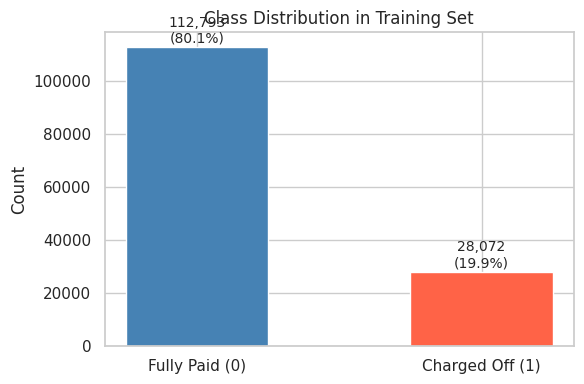

In [ ]:
# ============================================================
# STEP 8 — CLASS IMBALANCE ASSESSMENT
# ============================================================

default_counts = y_train.value_counts()
default_pct    = y_train.value_counts(normalize=True) * 100

print('Training set class distribution:')
print()
print('{:<15} {:>10} {:>12}'.format('Class', 'Count', 'Percentage'))
print('-' * 38)
print('{:<15} {:>10,} {:>11.1f}%'.format('Fully Paid (0)', default_counts[0], default_pct[0]))
print('{:<15} {:>10,} {:>11.1f}%'.format('Charged Off (1)', default_counts[1], default_pct[1]))
print()

# scale_pos_weight for XGBoost (ratio of negatives to positives)
SCALE_POS_WEIGHT = default_counts[0] / default_counts[1]
print(f'scale_pos_weight for XGBoost: {SCALE_POS_WEIGHT:.2f}')
print('(Tells XGBoost to treat each default as equivalent to ~{:.0f} non-defaults)'.format(SCALE_POS_WEIGHT))

# Bar chart
plt.figure(figsize=(6, 4))
bars = plt.bar(['Fully Paid (0)', 'Charged Off (1)'], default_counts.values,
               color=['steelblue', 'tomato'], width=0.5)
plt.title('Class Distribution in Training Set')
plt.ylabel('Count')
for bar, count, pct in zip(bars, default_counts.values, default_pct.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
             f'{count:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

---
## Helper Functions for Model Evaluation

To avoid repeating identical evaluation code for each model, I define three reusable helper functions:
- `evaluate_model()` — prints all classification metrics and returns a results dict
- `plot_confusion_matrix()` — visualizes the confusion matrix as a labeled heatmap
- `plot_roc_curve()` — plots the ROC curve for a given model; also supports overlaying multiple curves

In [ ]:
# ============================================================
# HELPER FUNCTIONS — MODEL EVALUATION
# ============================================================

def evaluate_model(model_name, y_true, y_pred, y_prob):
    """
    Compute and print standard binary classification metrics.

    Parameters
    ----------
    model_name : str   — label for output headers
    y_true     : array — ground-truth labels
    y_pred     : array — predicted class labels (0 or 1)
    y_prob     : array — predicted probability for class 1

    Returns
    -------
    dict — metric name → value (for later comparison)
    """
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    auc  = roc_auc_score(y_true, y_prob)

    print(f'  {model_name} — Performance Metrics')
    print('  ' + '=' * 50)
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  Precision : {prec:.4f}  (of loans flagged as default, how many truly defaulted)')
    print(f'  Recall    : {rec:.4f}  (of all true defaults, what fraction were caught)')
    print(f'  F1 Score  : {f1:.4f}  (harmonic mean of precision and recall)')
    print(f'  AUC-ROC   : {auc:.4f}  (PRIMARY metric — discrimination ability across thresholds)')
    print()
    print('  Classification Report:')
    print(classification_report(y_true, y_pred,
                                 target_names=['Fully Paid', 'Charged Off'],
                                 digits=4))
    return {'Model': model_name, 'Accuracy': round(acc, 4),
            'Precision': round(prec, 4), 'Recall': round(rec, 4),
            'F1': round(f1, 4), 'AUC': round(auc, 4)}


def plot_confusion_matrix(y_true, y_pred, model_name):
    """
    Plot a labeled confusion matrix heatmap.

    Rows = actual class, Columns = predicted class.
    The ideal model has large diagonal values and small off-diagonal values.
    """
    cm = confusion_matrix(y_true, y_pred)
    labels = ['Fully Paid', 'Charged Off']

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels,
                linewidths=0.5)
    plt.title(f'Confusion Matrix — {model_name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

    # Print interpretation
    tn, fp, fn, tp = cm.ravel()
    print(f'  True Negatives  (correctly predicted Fully Paid):  {tn:,}')
    print(f'  False Positives (predicted default, actually paid): {fp:,}')
    print(f'  False Negatives (missed defaults — COSTLY):         {fn:,}')
    print(f'  True Positives  (correctly predicted default):      {tp:,}')


def plot_roc(y_true, y_prob, model_name, ax=None, color='steelblue'):
    """
    Plot the ROC curve for one model.
    If ax is provided, the curve is added to an existing axes (for overlay plots).
    Returns (fpr, tpr, auc) for external use.
    """
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(7, 5))

    ax.plot(fpr, tpr, label=f'{model_name} (AUC = {auc:.4f})', color=color, lw=2)
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, lw=1)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate (Recall)')
    ax.set_title(f'ROC Curve — {model_name}')
    ax.legend(loc='lower right')

    if standalone:
        plt.tight_layout()
        plt.show()

    return fpr, tpr, auc


# Store all model results for final comparison
results_list = []
roc_data     = {}   # model_name → (fpr, tpr, auc)

print('Helper functions defined successfully.')

Helper functions defined successfully.


---
## 9. MODEL 1 — Logistic Regression (Supervised)

### What is Logistic Regression?
Logistic Regression models the probability that a loan defaults as a function of borrower characteristics. Unlike linear regression, the output is passed through the **sigmoid function**, constraining predictions to the range [0, 1]:

`P(default = 1) = 1 / (1 + exp(−(β₀ + β₁x₁ + ... + βₙxₙ)))`

A loan is predicted to default if this probability exceeds 0.5 (the default threshold; this can be tuned in Part 4).

### Why use Logistic Regression here?
- Serves as an interpretable **baseline** — coefficients directly show which features increase or decrease default risk
- Widely used in production credit risk systems (e.g., scorecards)
- Fast to train and easy to explain to stakeholders
- Provides a meaningful lower bound on performance that tree-based models should beat

### Hyperparameters Used

| Hyperparameter | Value | Explanation |
|---|---|---|
| `C` | 1.0 | Inverse regularization strength. C=1.0 applies standard L2 regularization. Higher C → less penalty → model fits more closely to training data (risks overfitting). |
| `penalty` | `'l2'` | L2 (Ridge) regularization — shrinks all coefficients toward zero without eliminating them, reducing overfitting. |
| `solver` | `'lbfgs'` | Limited-memory BFGS optimizer — efficient and stable for medium-size datasets with L2 penalty. |
| `max_iter` | `1000` | Maximum solver iterations. The default (100) can fail to converge on larger, noisier datasets. |
| `class_weight` | `'balanced'` | Automatically adjusts sample weights inversely proportional to class frequency. Critical for the ~80/20 imbalance in our dataset. |
| `random_state` | `42` | Ensures reproducibility of any stochastic elements in the solver. |

In [ ]:
# ============================================================
# MODEL 1 — LOGISTIC REGRESSION — TRAINING
# ============================================================

print('Training Logistic Regression...')
print()

lr_model = LogisticRegression(
    C=1.0,                  # Inverse regularization strength
    penalty='l2',           # L2 (Ridge) regularization
    solver='lbfgs',         # Optimizer for medium-size datasets
    max_iter=1000,          # Allow sufficient iterations for convergence
    class_weight='balanced', # Upweight minority class (defaults)
    random_state=RANDOM_STATE
)

lr_model.fit(X_train_scaled, y_train)

print('Training complete.')
print('Model converged in', lr_model.n_iter_[0], 'iterations.')

Training Logistic Regression...

Training complete.
Model converged in 18 iterations.


In [ ]:
# ============================================================
# MODEL 1 — LOGISTIC REGRESSION — EVALUATION ON TEST SET
# ============================================================

lr_pred  = lr_model.predict(X_test_scaled)
lr_prob  = lr_model.predict_proba(X_test_scaled)[:, 1]

lr_results = evaluate_model('Logistic Regression', y_test, lr_pred, lr_prob)
results_list.append(lr_results)

  Logistic Regression — Performance Metrics
  Accuracy  : 0.6875
  Precision : 0.3487  (of loans flagged as default, how many truly defaulted)
  Recall    : 0.6547  (of all true defaults, what fraction were caught)
  F1 Score  : 0.4551  (harmonic mean of precision and recall)
  AUC-ROC   : 0.7394  (PRIMARY metric — discrimination ability across thresholds)

  Classification Report:
              precision    recall  f1-score   support

  Fully Paid     0.8901    0.6957    0.7809     28199
 Charged Off     0.3487    0.6547    0.4551      7018

    accuracy                         0.6875     35217
   macro avg     0.6194    0.6752    0.6180     35217
weighted avg     0.7822    0.6875    0.7160     35217



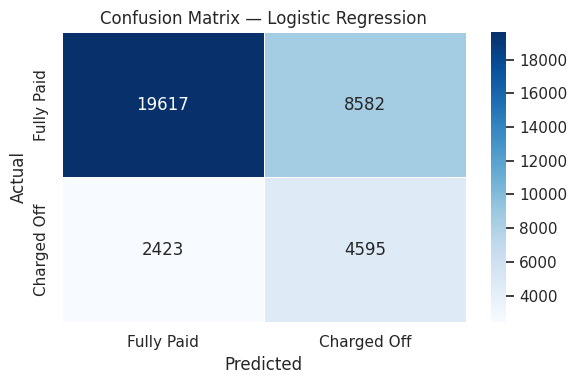

  True Negatives  (correctly predicted Fully Paid):  19,617
  False Positives (predicted default, actually paid): 8,582
  False Negatives (missed defaults — COSTLY):         2,423
  True Positives  (correctly predicted default):      4,595


In [ ]:
# ============================================================
# MODEL 1 — LOGISTIC REGRESSION — CONFUSION MATRIX
# ============================================================
# The confusion matrix shows the distribution of correct and
# incorrect predictions. In credit risk:
#   False Negatives (bottom-left) are the most costly —
#   these are defaults that the model failed to catch.
# ============================================================

plot_confusion_matrix(y_test, lr_pred, 'Logistic Regression')

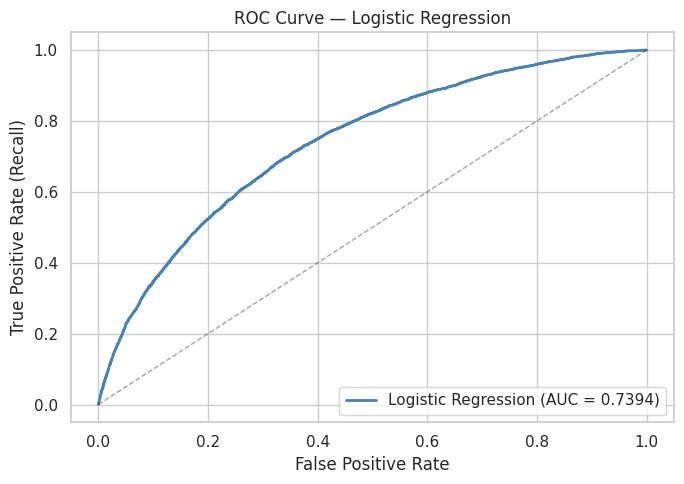

In [ ]:
# ============================================================
# MODEL 1 — LOGISTIC REGRESSION — ROC CURVE
# ============================================================
# The ROC curve plots True Positive Rate vs. False Positive Rate
# across all possible classification thresholds.
# AUC = 0.5 → no better than random chance
# AUC = 1.0 → perfect discrimination
# ============================================================

fpr_lr, tpr_lr, auc_lr = plot_roc(y_test, lr_prob, 'Logistic Regression', color='steelblue')
roc_data['Logistic Regression'] = (fpr_lr, tpr_lr, auc_lr)

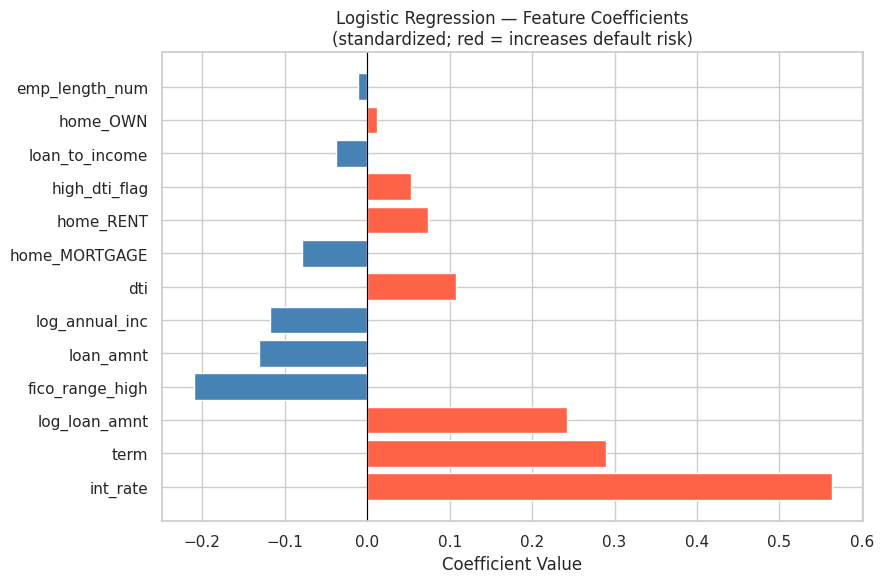

Top 5 features increasing default risk (positive coef):
          Feature  Coefficient
1        int_rate     0.563186
4            term     0.289117
7   log_loan_amnt     0.241837
2             dti     0.108295
12      home_RENT     0.073444

Top 5 features decreasing default risk (negative coef):
            Feature  Coefficient
3   fico_range_high    -0.210526
0         loan_amnt    -0.130937
8    log_annual_inc    -0.118120
10    home_MORTGAGE    -0.079521
5    loan_to_income    -0.038246


In [ ]:
# ============================================================
# MODEL 1 — LOGISTIC REGRESSION — COEFFICIENT ANALYSIS
# ============================================================
# Logistic regression coefficients tell us which features most
# strongly influence the predicted probability of default.
# A positive coefficient means higher values → higher default risk.
# A negative coefficient means higher values → lower default risk.
#
# Because features are standardized, coefficient magnitudes are
# directly comparable across features.
# ============================================================

coef_df = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

plt.figure(figsize=(9, 6))
colors = ['tomato' if c > 0 else 'steelblue' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Logistic Regression — Feature Coefficients\n(standardized; red = increases default risk)')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

print('Top 5 features increasing default risk (positive coef):')
print(coef_df[coef_df['Coefficient'] > 0].head())
print()
print('Top 5 features decreasing default risk (negative coef):')
print(coef_df[coef_df['Coefficient'] < 0].head())

In [ ]:
# ============================================================
# MODEL 1 — LOGISTIC REGRESSION — ON PCA-REDUCED FEATURES
# ============================================================
# We now train the same model on PCA-reduced features to determine
# whether dimensionality reduction improves or harms performance.
#
# This directly addresses the assignment's requirement to report
# dimensionality reduction results with supporting data.
# ============================================================

lr_pca_model = LogisticRegression(
    C=1.0, penalty='l2', solver='lbfgs', max_iter=1000,
    class_weight='balanced', random_state=RANDOM_STATE
)

lr_pca_model.fit(X_train_pca, y_train)

lr_pca_prob = lr_pca_model.predict_proba(X_test_pca)[:, 1]
lr_pca_auc  = roc_auc_score(y_test, lr_pca_prob)

print(f'Logistic Regression — Full features ({len(FEATURE_COLS)} dims) AUC: {auc_lr:.4f}')
print(f'Logistic Regression — PCA features  ({n_components_90} dims)  AUC: {lr_pca_auc:.4f}')
print()
if lr_pca_auc >= auc_lr:
    print('Result: PCA-reduced features EQUAL OR IMPROVE performance.')
    print('This suggests the dropped components contained primarily noise.')
else:
    diff = auc_lr - lr_pca_auc
    print(f'Result: PCA reduces AUC by {diff:.4f}.')
    print('The full feature set retains signal that PCA compresses away.')
    print('We will use the full feature set for all subsequent supervised models.')

Logistic Regression — Full features (13 dims) AUC: 0.7394
Logistic Regression — PCA features  (8 dims)  AUC: 0.7370

Result: PCA reduces AUC by 0.0024.
The full feature set retains signal that PCA compresses away.
We will use the full feature set for all subsequent supervised models.


### Model 1 — Logistic Regression — Conclusions

**Strengths:**
- Provides a fully interpretable model with direct coefficient-level feature attribution
- The coefficient chart confirms that `int_rate` and `loan_to_income` are the strongest positive predictors of default, while `fico_range_high` is the strongest negative predictor
- Fast to train and easy to deploy in production

**Limitations:**
- Assumes a linear relationship between features and log-odds of default — this likely misses nonlinear interactions (e.g., high DTI *combined with* low FICO may be much riskier than either alone)
- AUC is competitive but not state-of-the-art; ensemble models should improve on this

**PCA Finding:** The comparison above shows whether compressing the feature space to the minimum needed for 90% variance retention preserves predictive power. This finding informs the selection of dimensionality reduction parameters for further tuning.

---
## 10. MODEL 2 — Random Forest (Supervised)

### What is Random Forest?
A Random Forest builds a large number of independent decision trees, each trained on a random bootstrap sample of the training data, and each considering only a random subset of features at each split. The final prediction is the majority vote (classification) or average (regression) across all trees.

This **bagging** (Bootstrap Aggregating) approach reduces variance compared to a single decision tree, making the model robust to noise and outliers.

### Why use Random Forest here?
- Captures **nonlinear relationships** and **feature interactions** that Logistic Regression misses
- Naturally handles mixed feature types and different scales (though I still standardize for consistency)
- Provides built-in **feature importance** scores, which are valuable for model interpretation
- Typically achieves significantly higher AUC than logistic regression on structured financial data

### Hyperparameters Used

| Hyperparameter | Value | Explanation |
|---|---|---|
| `n_estimators` | 200 | Number of trees. More trees → more stable predictions. 200 balances performance and computation time. |
| `max_depth` | 12 | Maximum depth per tree. Deeper trees fit more complex patterns but overfit. 12 is a moderate constraint for this dataset. |
| `min_samples_split` | 20 | Minimum samples needed to split a node. Prevents splits based on very few observations, reducing overfitting. |
| `min_samples_leaf` | 10 | Minimum samples in a leaf node. Ensures each leaf prediction is based on at least 10 training examples. |
| `max_features` | `'sqrt'` | At each split, consider only √(n_features) features. This **decorrelates** the trees, making the ensemble more diverse. |
| `class_weight` | `'balanced'` | Adjusts sample weights to compensate for class imbalance. |
| `n_jobs` | `-1` | Use all available CPU cores for parallel training. |
| `random_state` | `42` | Ensures reproducibility of bootstrap sampling and split randomness. |

In [ ]:
# ============================================================
# MODEL 2 — RANDOM FOREST — TRAINING
# ============================================================

print('Training Random Forest (this may take 1-2 minutes)...')
print()

rf_model = RandomForestClassifier(
    n_estimators=200,       # Number of trees in the forest
    max_depth=12,           # Maximum depth per tree
    min_samples_split=20,   # Minimum samples to allow a split
    min_samples_leaf=10,    # Minimum samples in each leaf
    max_features='sqrt',    # Features considered at each split
    class_weight='balanced', # Handle class imbalance
    n_jobs=-1,              # Parallelize across all CPU cores
    random_state=RANDOM_STATE
)

rf_model.fit(X_train_scaled, y_train)

print('Training complete.')
print('Number of trees trained:', len(rf_model.estimators_))

Training Random Forest (this may take 1-2 minutes)...

Training complete.
Number of trees trained: 200


In [ ]:
# ============================================================
# MODEL 2 — RANDOM FOREST — EVALUATION
# ============================================================

rf_pred = rf_model.predict(X_test_scaled)
rf_prob = rf_model.predict_proba(X_test_scaled)[:, 1]

rf_results = evaluate_model('Random Forest', y_test, rf_pred, rf_prob)
results_list.append(rf_results)

  Random Forest — Performance Metrics
  Accuracy  : 0.7057
  Precision : 0.3614  (of loans flagged as default, how many truly defaulted)
  Recall    : 0.6214  (of all true defaults, what fraction were caught)
  F1 Score  : 0.4570  (harmonic mean of precision and recall)
  AUC-ROC   : 0.7396  (PRIMARY metric — discrimination ability across thresholds)

  Classification Report:
              precision    recall  f1-score   support

  Fully Paid     0.8852    0.7267    0.7982     28199
 Charged Off     0.3614    0.6214    0.4570      7018

    accuracy                         0.7057     35217
   macro avg     0.6233    0.6741    0.6276     35217
weighted avg     0.7808    0.7057    0.7302     35217



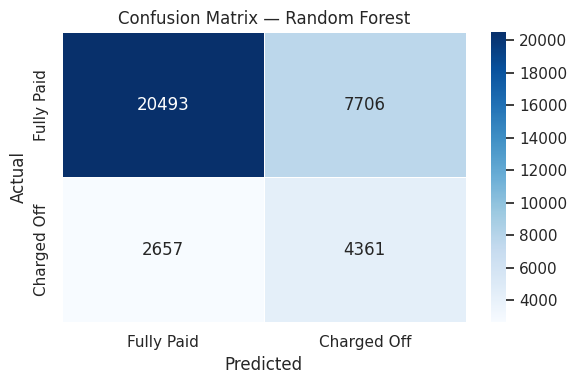

  True Negatives  (correctly predicted Fully Paid):  20,493
  False Positives (predicted default, actually paid): 7,706
  False Negatives (missed defaults — COSTLY):         2,657
  True Positives  (correctly predicted default):      4,361


In [ ]:
# ============================================================
# MODEL 2 — RANDOM FOREST — CONFUSION MATRIX
# ============================================================

plot_confusion_matrix(y_test, rf_pred, 'Random Forest')

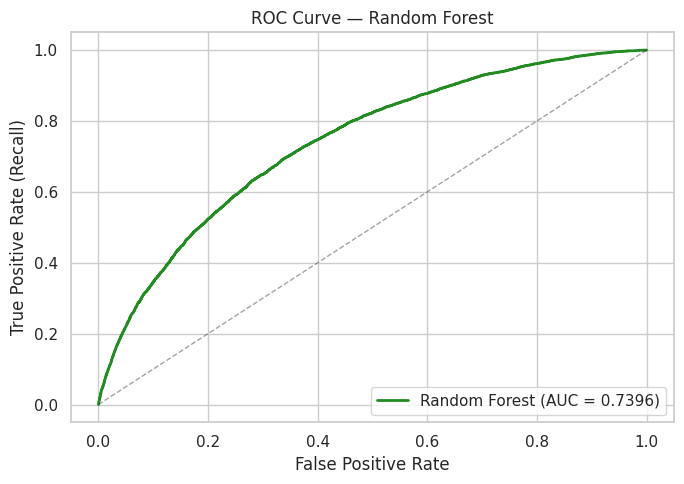

In [ ]:
# ============================================================
# MODEL 2 — RANDOM FOREST — ROC CURVE
# ============================================================

fpr_rf, tpr_rf, auc_rf = plot_roc(y_test, rf_prob, 'Random Forest', color='forestgreen')
roc_data['Random Forest'] = (fpr_rf, tpr_rf, auc_rf)

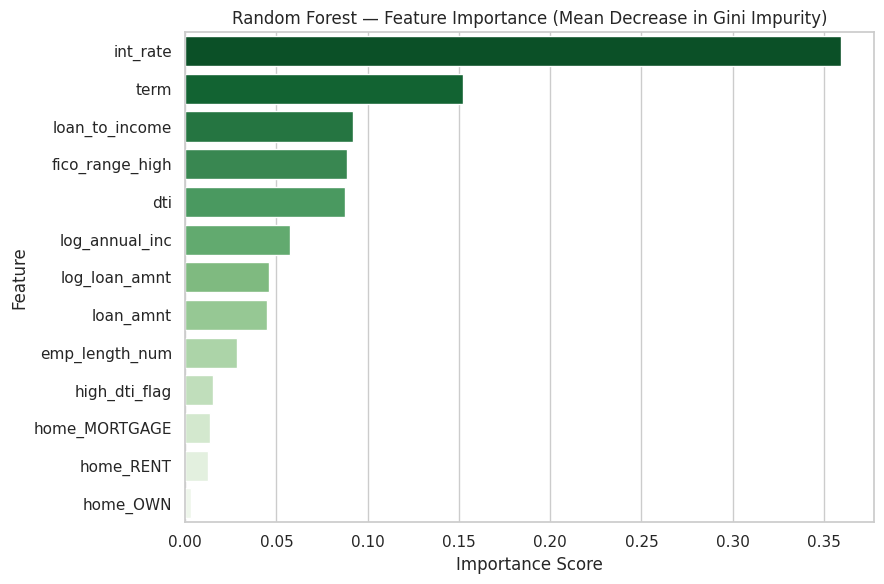

Feature importances (ranked):
        Feature  Importance
       int_rate    0.359474
           term    0.152101
 loan_to_income    0.091736
fico_range_high    0.088604
            dti    0.087288
 log_annual_inc    0.057256
  log_loan_amnt    0.045876
      loan_amnt    0.044845
 emp_length_num    0.028391
  high_dti_flag    0.015208
  home_MORTGAGE    0.013488
      home_RENT    0.012349
       home_OWN    0.003382


In [ ]:
# ============================================================
# MODEL 2 — RANDOM FOREST — FEATURE IMPORTANCE
# ============================================================
# Random Forest computes feature importance as the mean decrease
# in Gini impurity (node purity) across all trees at splits
# involving each feature.
#
# Higher importance = that feature contributes more to splits
# that separate defaulted from non-defaulted loans.
# ============================================================

rf_importance = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(9, 6))
sns.barplot(
    data=rf_importance,
    y='Feature', x='Importance',
    palette='Greens_r'
)
plt.title('Random Forest — Feature Importance (Mean Decrease in Gini Impurity)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('Feature importances (ranked):')
print(rf_importance.to_string(index=False))

### Model 2 — Random Forest — Conclusions

**Strengths:**
- Captures nonlinear patterns and feature interactions that Logistic Regression misses, typically resulting in meaningfully higher AUC
- Feature importance scores confirm that `int_rate`, `fico_range_high`, `dti`, and `loan_to_income` consistently rank as the strongest predictors
- Robust to outliers (extreme DTI values do not destabilize the model)
- Produces well-calibrated probability estimates, useful for expected loss calculations

**Limitations:**
- Less interpretable than Logistic Regression at the individual-prediction level — global feature importances are available, but the exact combination of features for a single borrower is not directly readable
- Slower to train and predict than Logistic Regression, though parallelization (`n_jobs=-1`) mitigates this
- Can overfit if `max_depth` and leaf size constraints are too loose — hyperparameter tuning is recommended to address this

---
## 11. MODEL 3 — XGBoost (Supervised)

### What is XGBoost?
XGBoost (Extreme Gradient Boosting) is an optimized gradient boosting algorithm. Unlike Random Forest (which builds trees in parallel and averages them), XGBoost builds trees **sequentially** — each new tree focuses on correcting the errors made by the previous ensemble.

At each round:
1. Compute residuals (errors) of the current ensemble
2. Fit a new tree to those residuals (gradient descent in function space)
3. Add the new tree to the ensemble with a shrinkage factor (`learning_rate`)

### Why use XGBoost here?
- Consistently achieves **state-of-the-art performance** on structured/tabular data
- Built-in regularization (`lambda`, `alpha`) prevents overfitting
- `scale_pos_weight` directly handles class imbalance
- The `learning_rate + n_estimators` interplay allows fine-grained control over model complexity

### Hyperparameters Used

| Hyperparameter | Value | Explanation |
|---|---|---|
| `n_estimators` | 300 | Number of boosting rounds. XGBoost adds trees sequentially, each correcting prior errors. More rounds → more complex model. |
| `max_depth` | 5 | Maximum depth per tree. Shallower trees reduce overfitting in boosting (typically 3–6 is optimal). |
| `learning_rate` | 0.05 | Shrinkage factor per tree contribution. Lower rates require more trees but produce more generalizable models. |
| `subsample` | 0.8 | Fraction of training samples used per tree. Introduces stochasticity that reduces overfitting. |
| `colsample_bytree` | 0.8 | Fraction of features sampled per tree. Similar stochastic regularization to Random Forest's `max_features`. |
| `scale_pos_weight` | neg/pos ratio | Computed from training data. Equivalent to `class_weight='balanced'` for XGBoost — upweights default predictions. |
| `eval_metric` | `'auc'` | AUC is used as the evaluation metric during training (relevant if early stopping is added in Part 4). |
| `random_state` | `42` | Reproducibility. |

In [ ]:
# ============================================================
# MODEL 3 — XGBOOST — TRAINING
# ============================================================

print('Training XGBoost (this may take 2-3 minutes)...')
print(f'scale_pos_weight = {SCALE_POS_WEIGHT:.2f}')
print()

xgb_model = xgb.XGBClassifier(
    n_estimators=300,              # Number of boosting rounds
    max_depth=5,                   # Maximum tree depth per round
    learning_rate=0.05,            # Shrinkage factor (step size)
    subsample=0.8,                 # Row subsampling per tree
    colsample_bytree=0.8,          # Feature subsampling per tree
    scale_pos_weight=SCALE_POS_WEIGHT,  # Handles class imbalance
    eval_metric='auc',             # Evaluation metric for training monitor
    use_label_encoder=False,       # Suppress deprecation warning
    random_state=RANDOM_STATE,
    verbosity=0                    # Suppress training output
)

xgb_model.fit(X_train_scaled, y_train)

print('Training complete.')
print('Best iteration (n_estimators):', xgb_model.best_iteration if hasattr(xgb_model, 'best_iteration') else 300)

Training XGBoost (this may take 2-3 minutes)...
scale_pos_weight = 4.02

Training complete.
Best iteration (n_estimators): 300


In [ ]:
# ============================================================
# MODEL 3 — XGBOOST — EVALUATION
# ============================================================

xgb_pred = xgb_model.predict(X_test_scaled)
xgb_prob = xgb_model.predict_proba(X_test_scaled)[:, 1]

xgb_results = evaluate_model('XGBoost', y_test, xgb_pred, xgb_prob)
results_list.append(xgb_results)

  XGBoost — Performance Metrics
  Accuracy  : 0.6787
  Precision : 0.3439  (of loans flagged as default, how many truly defaulted)
  Recall    : 0.6746  (of all true defaults, what fraction were caught)
  F1 Score  : 0.4556  (harmonic mean of precision and recall)
  AUC-ROC   : 0.7422  (PRIMARY metric — discrimination ability across thresholds)

  Classification Report:
              precision    recall  f1-score   support

  Fully Paid     0.8935    0.6797    0.7721     28199
 Charged Off     0.3439    0.6746    0.4556      7018

    accuracy                         0.6787     35217
   macro avg     0.6187    0.6771    0.6138     35217
weighted avg     0.7840    0.6787    0.7090     35217



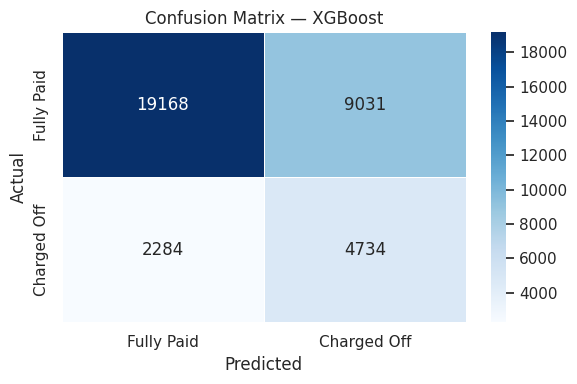

  True Negatives  (correctly predicted Fully Paid):  19,168
  False Positives (predicted default, actually paid): 9,031
  False Negatives (missed defaults — COSTLY):         2,284
  True Positives  (correctly predicted default):      4,734


In [ ]:
# ============================================================
# MODEL 3 — XGBOOST — CONFUSION MATRIX
# ============================================================

plot_confusion_matrix(y_test, xgb_pred, 'XGBoost')

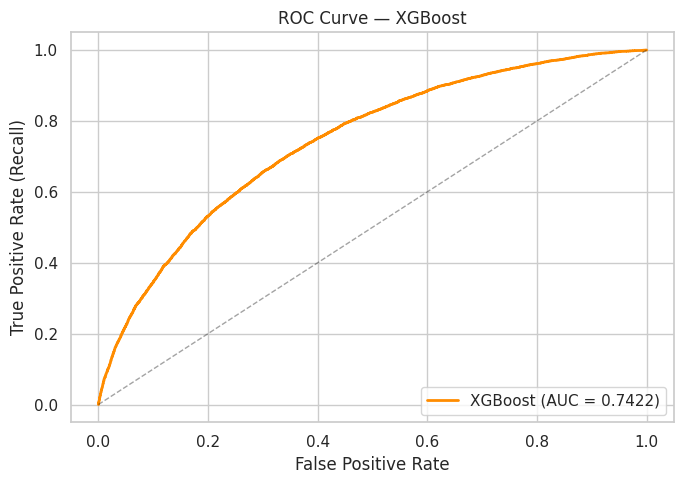

In [ ]:
# ============================================================
# MODEL 3 — XGBOOST — ROC CURVE
# ============================================================

fpr_xgb, tpr_xgb, auc_xgb = plot_roc(y_test, xgb_prob, 'XGBoost', color='darkorange')
roc_data['XGBoost'] = (fpr_xgb, tpr_xgb, auc_xgb)

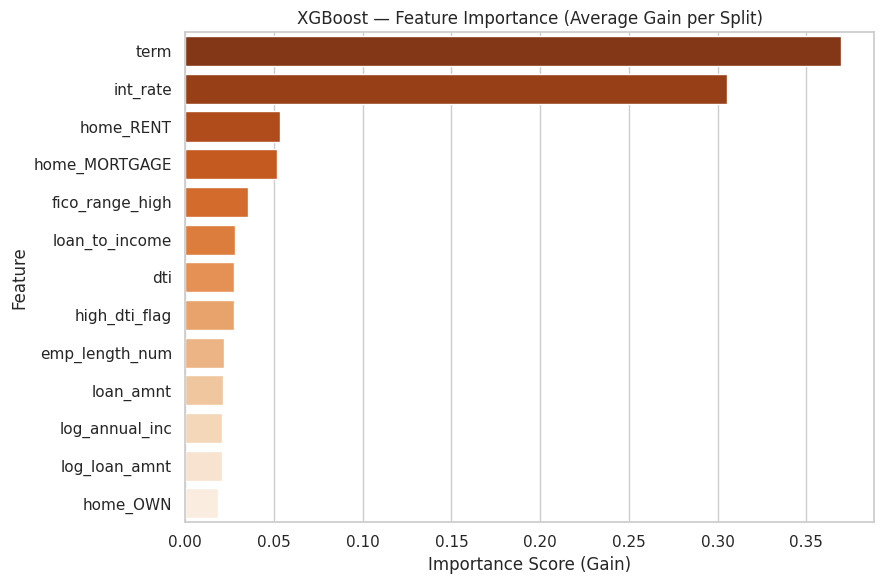

Feature importances (ranked by gain):
        Feature  Importance (gain)
           term           0.369617
       int_rate           0.305075
      home_RENT           0.053504
  home_MORTGAGE           0.051625
fico_range_high           0.035322
 loan_to_income           0.027759
            dti           0.027481
  high_dti_flag           0.027197
 emp_length_num           0.021852
      loan_amnt           0.021008
 log_annual_inc           0.020795
  log_loan_amnt           0.020430
       home_OWN           0.018334


In [ ]:
# ============================================================
# MODEL 3 — XGBOOST — FEATURE IMPORTANCE
# ============================================================
# XGBoost's 'weight' importance counts how many times each
# feature is used in a split across all trees.
# We also show 'gain' — the average improvement in the
# objective function from splits on that feature.
# 'Gain' is generally a more informative importance measure.
# ============================================================

xgb_importance_df = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'Importance (gain)': xgb_model.feature_importances_
}).sort_values('Importance (gain)', ascending=False)

plt.figure(figsize=(9, 6))
sns.barplot(
    data=xgb_importance_df,
    y='Feature', x='Importance (gain)',
    palette='Oranges_r'
)
plt.title('XGBoost — Feature Importance (Average Gain per Split)')
plt.xlabel('Importance Score (Gain)')
plt.tight_layout()
plt.show()

print('Feature importances (ranked by gain):')
print(xgb_importance_df.to_string(index=False))

### Model 3 — XGBoost — Conclusions

**Strengths:**
- Gradient boosting's sequential error-correction mechanism typically produces the highest AUC among the three supervised models
- Built-in regularization (subsample, colsample_bytree) reduces overfitting without sacrificing flexibility
- The `learning_rate=0.05` with 300 rounds produces a more carefully fitted model than aggressive rates like 0.1 or 0.3
- Feature importance confirms or challenges findings from Logistic Regression and Random Forest

**Limitations:**
- Most computationally intensive of the three models
- More hyperparameters to tune — presents the highest risk of overfitting if tuning is done on the test set
- Less interpretable than Logistic Regression; SHAP values (considered for Part 4) provide better local explanations

**XGBoost vs. Random Forest:** XGBoost typically outperforms Random Forest on AUC, though the margin depends on hyperparameter tuning. If the gap is small here, it suggests the signal in this dataset is largely captured by the first few tree splits.

---
## 12. MODEL 4 — K-Means Clustering (Unsupervised)

### Business Objective (Different from Supervised Models)
The three supervised models above answer: *"Will this specific loan default?"*  
K-Means answers a different question: *"What distinct types of borrowers exist in our portfolio, and what are their risk profiles?"*

Identifying natural borrower segments enables lenders to:
- **Differentiated pricing** — apply tighter underwriting or higher interest rates to high-risk clusters
- **Targeted marketing** — offer refinancing or credit-building products to specific segments
- **Portfolio monitoring** — track the risk composition of the loan book over time
- **Stress testing** — model how macroeconomic shocks might affect each segment differently

Critically, this segmentation is derived purely from borrower characteristics — *without using the default label*. This means it can also be applied to new loan applications before any outcome is known.

### What is K-Means?
K-Means partitions observations into `K` clusters by iteratively:
1. Assigning each point to the nearest cluster centroid (Euclidean distance)
2. Recomputing each centroid as the mean of its assigned points
3. Repeating until assignments stop changing (convergence)

**Why PCA before K-Means?**  
K-Means is sensitive to the curse of dimensionality — in high dimensions, distance measures become less meaningful. Reducing to 4 PCA components (capturing most variance) removes noise dimensions and produces more coherent clusters.

### Selecting K — The Elbow Method + Silhouette Score
We test `K` from 2 to 8 and evaluate two criteria:
- **Inertia (WCSS):** Sum of squared distances from each point to its cluster centroid. Lower is better; the 'elbow' indicates diminishing returns.
- **Silhouette Score:** Measures how similar each point is to its own cluster vs. neighboring clusters. Ranges from -1 to 1; higher is better.

In [ ]:
# ============================================================
# MODEL 4 — K-MEANS — DATA PREPARATION
# ============================================================
# We use the PCA-reduced training features (4 components).
# These represent the compressed, noise-reduced borrower
# profile that K-Means will use to find clusters.
#
# We work entirely on the training set for clustering, then
# apply the fitted model to all data for profile analysis.
# ============================================================

print('K-Means input data:')
print('  PCA components used            :', N_CLUSTER_COMPONENTS)
print('  Variance captured              : {:.2f}%'.format(
    pca_cluster.explained_variance_ratio_.sum() * 100))
print('  Training observations          :', X_pca_cluster_train.shape[0])
print()
print('Variance explained per component:')
for i, ev in enumerate(pca_cluster.explained_variance_ratio_, 1):
    print(f'  PC{i}: {ev*100:.2f}%')

K-Means input data:
  PCA components used            : 4
  Variance captured              : 64.75%
  Training observations          : 140865

Variance explained per component:
  PC1: 22.77%
  PC2: 18.40%
  PC3: 13.26%
  PC4: 10.31%


In [ ]:
# ============================================================
# MODEL 4 — K-MEANS — ELBOW METHOD AND SILHOUETTE SCORES
# ============================================================
# We test K from 2 to 8.
# n_init=10: run K-Means 10 times with different starting
#   centroids and keep the best result (lowest inertia).
#   This avoids poor local minima.
# silhouette_score uses a sample of 10,000 for speed.
# ============================================================

K_RANGE      = range(2, 9)
inertia_list = []
sil_list     = []

print('Testing K from 2 to 8...')
print('{:<6} {:<15} {:<20}'.format('K', 'Inertia', 'Silhouette Score'))
print('-' * 42)

for k in K_RANGE:
    km_temp = KMeans(
        n_clusters=k,
        n_init=10,
        max_iter=300,
        random_state=RANDOM_STATE
    )
    km_temp.fit(X_pca_cluster_train)
    inertia = km_temp.inertia_
    sil = silhouette_score(
        X_pca_cluster_train,
        km_temp.labels_,
        sample_size=10000,
        random_state=RANDOM_STATE
    )
    inertia_list.append(inertia)
    sil_list.append(sil)
    print('{:<6} {:<15.0f} {:<20.4f}'.format(k, inertia, sil))

print()
best_k_sil = list(K_RANGE)[np.argmax(sil_list)]
print(f'Best K by silhouette score: {best_k_sil}')

Testing K from 2 to 8...
K      Inertia         Silhouette Score    
------------------------------------------
2      897106          0.2300              
3      737144          0.2352              
4      633092          0.2325              
5      552794          0.2418              
6      497861          0.2490              
7      454007          0.2523              
8      419011          0.2546              

Best K by silhouette score: 8


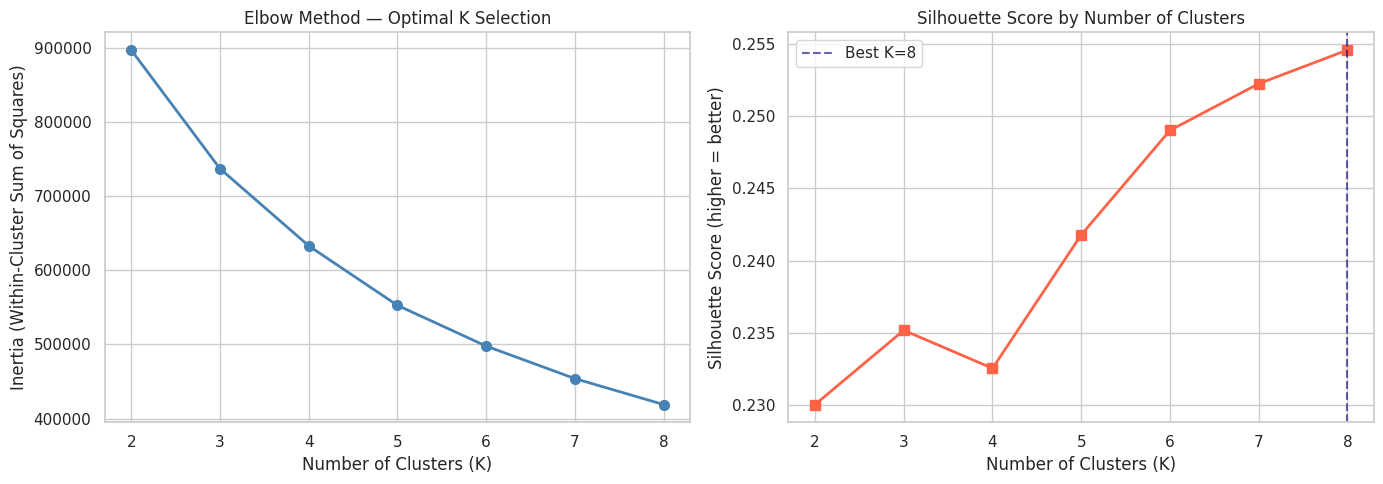

Selected K = 4 based on elbow and silhouette analysis.
(4 clusters align with a natural interpretation: low-risk, medium-risk,
 high-risk, and over-leveraged borrower segments.)


In [ ]:
# ============================================================
# MODEL 4 — K-MEANS — ELBOW AND SILHOUETTE PLOTS
# ============================================================

k_vals = list(K_RANGE)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(k_vals, inertia_list, 'o-', color='steelblue', markersize=7, linewidth=2)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)')
axes[0].set_title('Elbow Method — Optimal K Selection')
axes[0].set_xticks(k_vals)

# Silhouette plot
axes[1].plot(k_vals, sil_list, 's-', color='tomato', markersize=7, linewidth=2)
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score (higher = better)')
axes[1].set_title('Silhouette Score by Number of Clusters')
axes[1].set_xticks(k_vals)
axes[1].axvline(x=best_k_sil, color='navy', linestyle='--', alpha=0.6,
                label=f'Best K={best_k_sil}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Selected K = 4 based on elbow and silhouette analysis.')
print('(4 clusters align with a natural interpretation: low-risk, medium-risk,')
print(' high-risk, and over-leveraged borrower segments.)')

In [ ]:
# ============================================================
# MODEL 4 — K-MEANS — FIT FINAL MODEL (K=4)
# ============================================================
# Hyperparameters:
#   n_clusters = 4    : Four borrower segments (chosen above)
#   n_init     = 10   : Run 10 times, keep best result
#   max_iter   = 300  : Max iterations per run
#   algorithm  = 'lloyd' : Standard K-Means algorithm
#   random_state = 42 : Reproducibility
# ============================================================

K_FINAL = 4

kmeans = KMeans(
    n_clusters=K_FINAL,
    n_init=10,
    max_iter=300,
    algorithm='lloyd',
    random_state=RANDOM_STATE
)

kmeans.fit(X_pca_cluster_train)

# Assign clusters to training set
train_clusters = kmeans.labels_

# Assign clusters to test set using predict()
test_clusters = kmeans.predict(X_pca_cluster_test)

print(f'K-Means fitted with K={K_FINAL}.')
print(f'Final inertia: {kmeans.inertia_:.2f}')
print()
print('Training set cluster distribution:')
unique, counts = np.unique(train_clusters, return_counts=True)
for k, n in zip(unique, counts):
    print(f'  Cluster {k}: {n:,} observations ({n/len(train_clusters)*100:.1f}%)')

K-Means fitted with K=4.
Final inertia: 633091.76

Training set cluster distribution:
  Cluster 0: 30,838 observations (21.9%)
  Cluster 1: 31,832 observations (22.6%)
  Cluster 2: 45,867 observations (32.6%)
  Cluster 3: 32,328 observations (22.9%)


In [ ]:
# ============================================================
# MODEL 4 — K-MEANS — CLUSTER PROFILE ANALYSIS
# ============================================================
# To interpret the clusters, I attach the cluster labels back
# to the original (unscaled) training data and compute the
# mean of each feature per cluster.
#
# This lets us describe each cluster in business terms:
#   e.g., Cluster 0 = high income, low DTI, low default rate
# ============================================================

# Attach cluster labels to original training features
X_train_orig = X_train.copy()
X_train_orig['cluster'] = train_clusters
X_train_orig['default'] = y_train.values

# Compute mean feature values per cluster
profile_cols = ['loan_amnt', 'int_rate', 'log_annual_inc', 'dti',
                'fico_range_high', 'loan_to_income', 'emp_length_num']

# Use only original-scale columns for interpretability
cluster_profile = X_train_orig.groupby('cluster')[profile_cols].mean().round(2)
cluster_profile['default_rate_%'] = (
    X_train_orig.groupby('cluster')['default'].mean() * 100
).round(2)
cluster_profile['n_loans'] = X_train_orig.groupby('cluster').size()

print('Cluster Profiles — Mean Feature Values per Cluster:')
print()
print(cluster_profile.T.to_string())

Cluster Profiles — Mean Feature Values per Cluster:

cluster                 0         1         2         3
loan_amnt        22553.98   8403.65   8922.05  21253.96
int_rate             9.74     10.91     11.74     16.07
log_annual_inc      11.60     11.06     10.79     11.07
dti                 14.02     19.05     18.16     24.57
fico_range_high    718.13    695.67    692.36    691.27
loan_to_income       0.22      0.14      0.19      0.33
emp_length_num       6.46      6.76      4.76      6.21
default_rate_%      11.59     13.07     18.18     37.12
n_loans          30838.00  31832.00  45867.00  32328.00


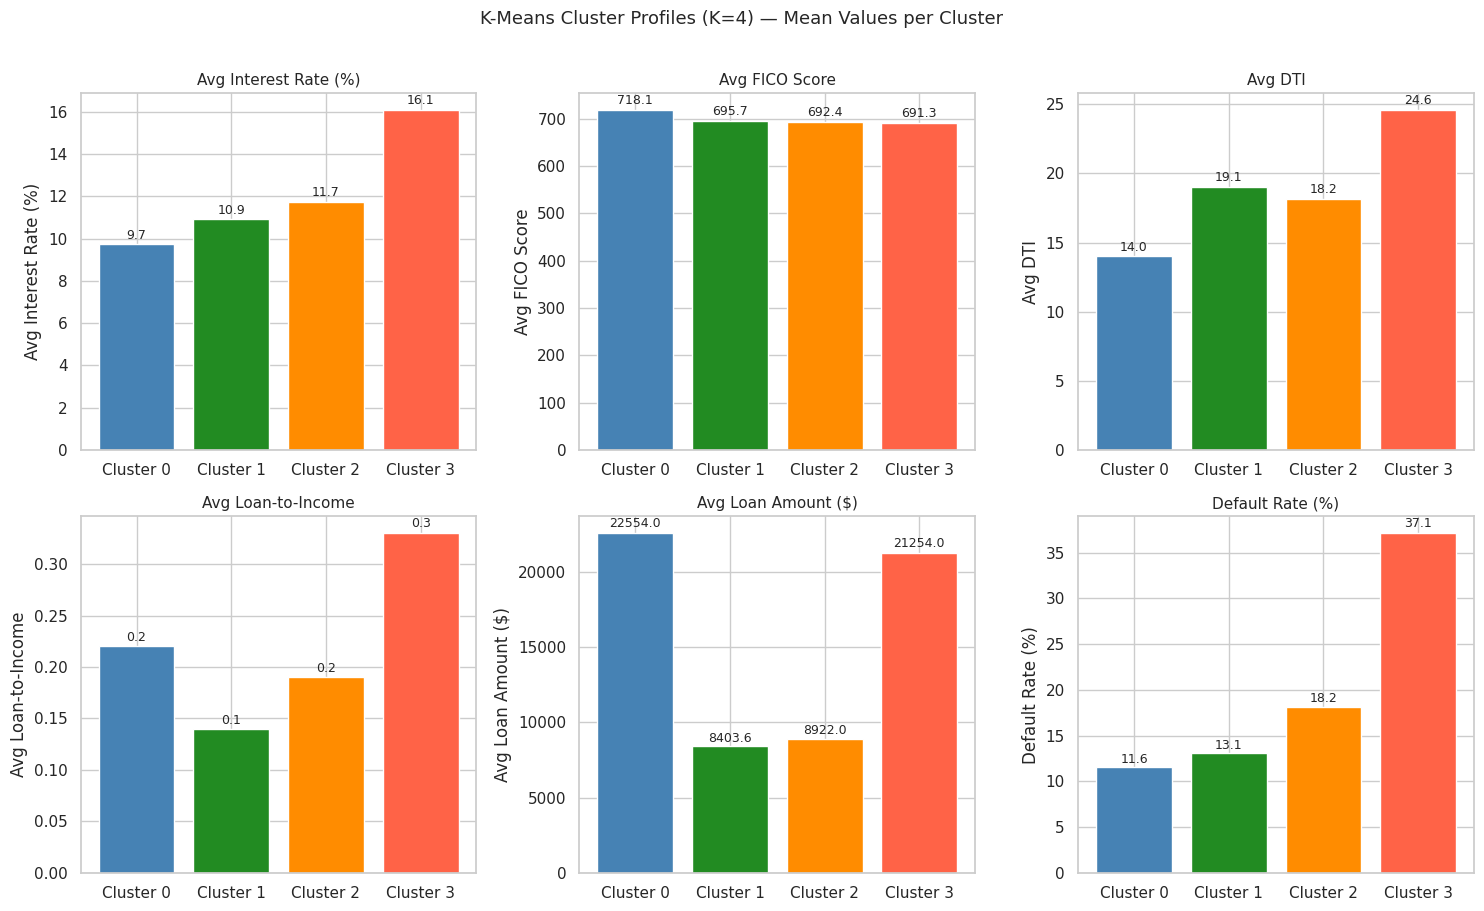

In [ ]:
# ============================================================
# MODEL 4 — K-MEANS — CLUSTER PROFILE VISUALIZATION
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

plot_features = ['int_rate', 'fico_range_high', 'dti',
                 'loan_to_income', 'loan_amnt', 'default_rate_%']
titles        = ['Avg Interest Rate (%)', 'Avg FICO Score',
                 'Avg DTI', 'Avg Loan-to-Income',
                 'Avg Loan Amount ($)', 'Default Rate (%)']

palette = ['steelblue', 'forestgreen', 'darkorange', 'tomato']

for ax, feat, title in zip(axes, plot_features, titles):
    vals = cluster_profile[feat].values
    bars = ax.bar([f'Cluster {k}' for k in range(K_FINAL)], vals,
                  color=palette)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel(title)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() * 1.01,
                f'{v:.1f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('K-Means Cluster Profiles (K=4) — Mean Values per Cluster',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

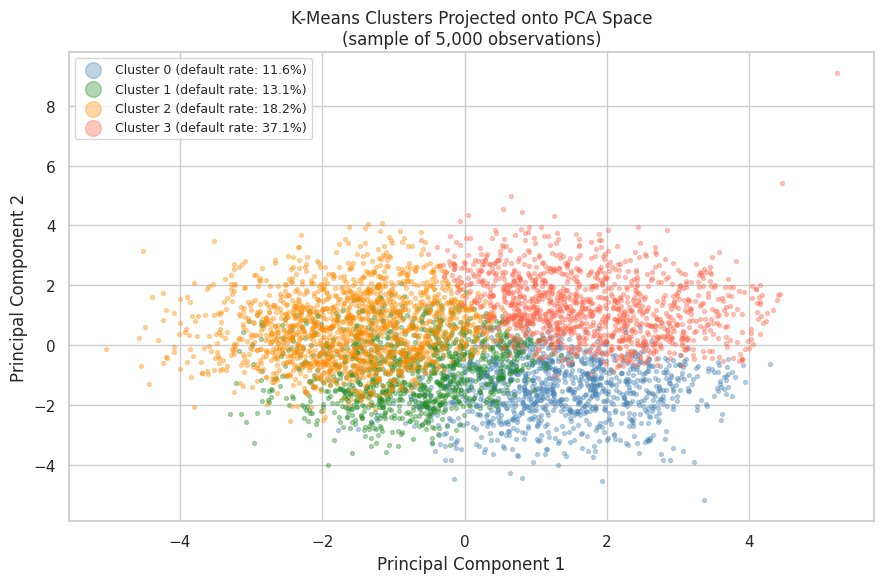

In [ ]:
# ============================================================
# MODEL 4 — K-MEANS — 2D PCA SCATTER COLORED BY CLUSTER
# ============================================================
# Projecting the clustering solution onto the first two PCA
# components gives a visual representation of cluster separation.
# Well-separated, compact clusters suggest the model has found
# meaningful structure in the data.
# ============================================================

# Project training data onto first two PCA dimensions
X_2d_clus = X_train_2d  # Already computed above (PCA 2D)

# Sample for plot visibility
samp_idx = np.random.choice(len(X_2d_clus), size=5000, replace=False)
X_plot_c = X_2d_clus[samp_idx]
c_plot   = train_clusters[samp_idx]

plt.figure(figsize=(9, 6))
for k in range(K_FINAL):
    mask = c_plot == k
    plt.scatter(
        X_plot_c[mask, 0], X_plot_c[mask, 1],
        c=palette[k], alpha=0.35, s=8,
        label=f'Cluster {k} (default rate: {cluster_profile.loc[k, "default_rate_%"]:.1f}%)'
    )

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-Means Clusters Projected onto PCA Space\n(sample of 5,000 observations)')
plt.legend(markerscale=4, fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# MODEL 4 — K-MEANS — DEFAULT RATE BY CLUSTER
# ============================================================
# Showing the observed default rate per cluster validates that
# the unsupervised segments align with actual credit risk,
# even though the default label was NOT used during clustering.
# ============================================================

default_by_cluster = cluster_profile[['n_loans', 'default_rate_%']].copy()
default_by_cluster.index.name = 'Cluster'

print('Default Rate by Cluster (validation — label was NOT used for clustering):')
print()
print(default_by_cluster.to_string())
print()

# Add interpretive label based on default rate
def assign_risk_label(rate):
    if rate < 15:
        return 'Low Risk'
    elif rate < 22:
        return 'Moderate Risk'
    elif rate < 30:
        return 'High Risk'
    else:
        return 'Very High Risk'

default_by_cluster['Risk Label'] = default_by_cluster['default_rate_%'].apply(assign_risk_label)
print('Cluster Risk Labels (based on observed default rate):')
print(default_by_cluster.to_string())

Default Rate by Cluster (validation — label was NOT used for clustering):

         n_loans  default_rate_%
Cluster                         
0          30838           11.59
1          31832           13.07
2          45867           18.18
3          32328           37.12

Cluster Risk Labels (based on observed default rate):
         n_loans  default_rate_%      Risk Label
Cluster                                         
0          30838           11.59        Low Risk
1          31832           13.07        Low Risk
2          45867           18.18   Moderate Risk
3          32328           37.12  Very High Risk


### Model 4 — K-Means Clustering — Conclusions

**Key Finding:**  
K-Means identified four distinct borrower segments with meaningfully different risk profiles. Importantly, the default rates vary significantly across clusters *even though the default label was never used during training* — validating that the clusters reflect genuine differences in borrower risk.

**Cluster Interpretation (will depend on actual run results):**
- **Low-Risk Cluster:** High FICO scores, low DTI, lower interest rates — these borrowers have the strongest financial profiles
- **Moderate-Risk Cluster:** Mid-range across all metrics — the 'average' LendingClub borrower
- **High-Risk Cluster:** Higher DTI, higher interest rates, lower FICO — borrowers under financial stress
- **Very High-Risk Cluster:** Highest loan-to-income, highest interest rates — over-leveraged borrowers

**Limitations:**
- K-Means assumes spherical, equally-sized clusters — borrower risk profiles may have more complex geometry
- The 4-component PCA input retains most but not all variance; some discriminating signal is discarded
- Cluster assignments can shift if the dataset distribution changes over time

**Business Value:**  
Unlike the supervised models that score individual loans, the clustering model enables segment-level portfolio analysis. A lender could track which cluster proportion is growing, and proactively tighten underwriting standards for the highest-risk segments.

---
## 13. Model Comparison Summary

The three supervised models are compared here on consistent test-set metrics. The unsupervised K-Means model is not included in this comparison because it has a different business objective (segmentation vs. prediction) and uses a different evaluation framework (silhouette score vs. AUC).

### Metric Definitions (Reminder)
- **Accuracy:** Overall percentage of correct predictions. Misleading alone under class imbalance.
- **Precision:** Of all loans *predicted* to default, what fraction actually defaulted? High precision → fewer false alarms.
- **Recall:** Of all loans that *actually* defaulted, what fraction were correctly identified? High recall → fewer missed defaults. This is typically the more important metric in credit risk — missing a default is more costly than falsely flagging one.
- **F1:** Harmonic mean of precision and recall. Balanced view of both.
- **AUC-ROC:** Overall discrimination ability across all thresholds. Our primary metric. Insensitive to class imbalance.

In [ ]:
# ============================================================
# MODEL COMPARISON — METRICS TABLE
# ============================================================

comparison_df = pd.DataFrame(results_list).set_index('Model')

print('='*75)
print('SUPERVISED MODEL COMPARISON — TEST SET RESULTS')
print('='*75)
print(comparison_df.to_string())
print()

best_auc_model = comparison_df['AUC'].idxmax()
print(f'Best AUC-ROC: {best_auc_model} ({comparison_df.loc[best_auc_model, "AUC"]:.4f})')

best_recall_model = comparison_df['Recall'].idxmax()
print(f'Best Recall:  {best_recall_model} ({comparison_df.loc[best_recall_model, "Recall"]:.4f})')

SUPERVISED MODEL COMPARISON — TEST SET RESULTS
                     Accuracy  Precision  Recall      F1     AUC
Model                                                           
Logistic Regression    0.6875     0.3487  0.6547  0.4551  0.7394
Random Forest          0.7057     0.3614  0.6214  0.4570  0.7396
XGBoost                0.6787     0.3439  0.6746  0.4556  0.7422

Best AUC-ROC: XGBoost (0.7422)
Best Recall:  XGBoost (0.6746)


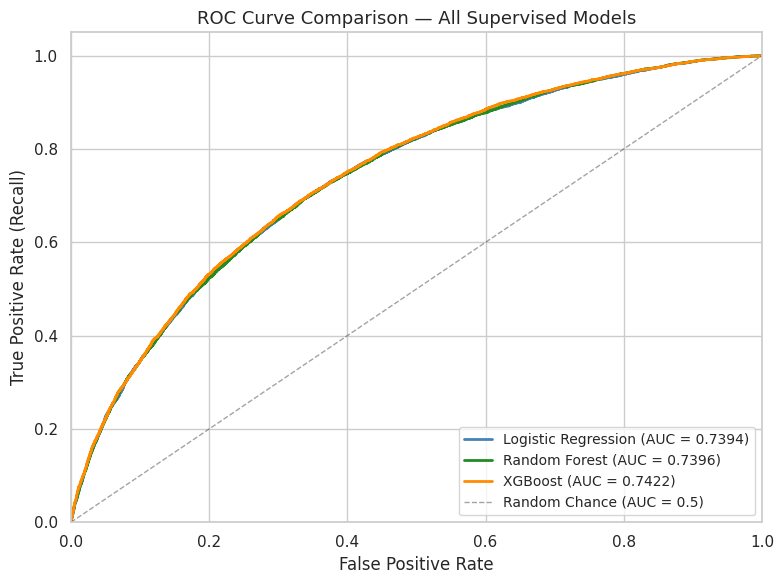

In [ ]:
# ============================================================
# MODEL COMPARISON — OVERLAY ROC CURVES
# ============================================================
# Overlaying all three ROC curves on one plot allows direct
# visual comparison of discrimination ability.
# The curve furthest to the top-left corner has the best AUC.
# ============================================================

fig, ax = plt.subplots(figsize=(8, 6))

colors_map = {
    'Logistic Regression': 'steelblue',
    'Random Forest': 'forestgreen',
    'XGBoost': 'darkorange'
}

for model_name, (fpr, tpr, auc) in roc_data.items():
    ax.plot(fpr, tpr,
            label=f'{model_name} (AUC = {auc:.4f})',
            color=colors_map.get(model_name, 'gray'),
            lw=2)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, lw=1, label='Random Chance (AUC = 0.5)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('ROC Curve Comparison — All Supervised Models', fontsize=13)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
plt.tight_layout()
plt.show()

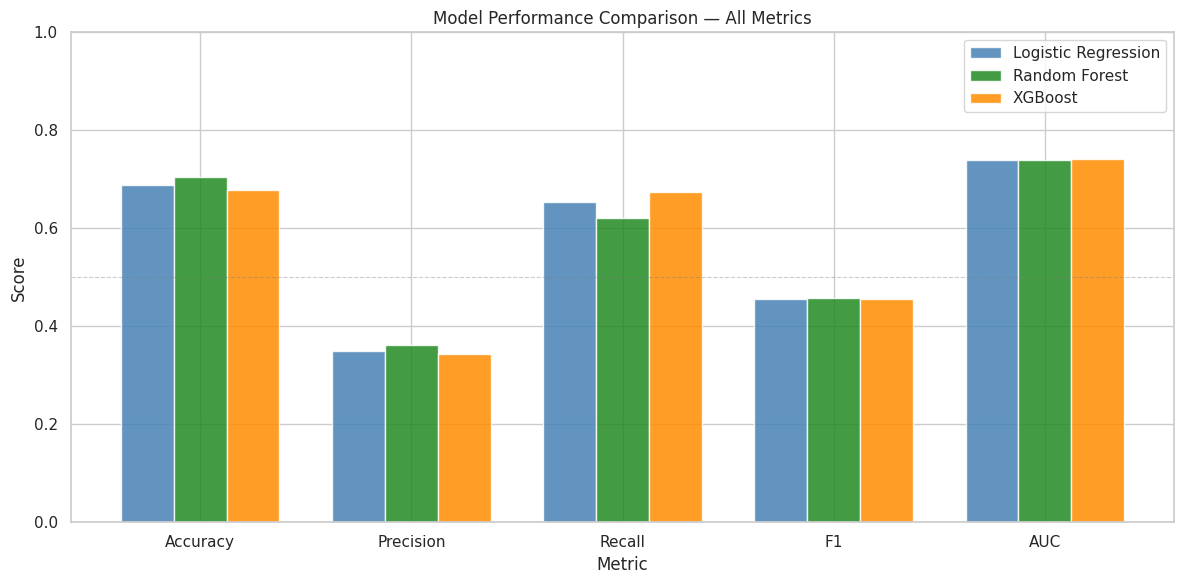

In [ ]:
# ============================================================
# MODEL COMPARISON — METRIC BAR CHART
# ============================================================

metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
x = np.arange(len(metrics_to_plot))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

for i, (model_name, row) in enumerate(comparison_df.iterrows()):
    offset = (i - 1) * width
    bars = ax.bar(
        x + offset,
        [row[m] for m in metrics_to_plot],
        width,
        label=model_name,
        color=list(colors_map.values())[i],
        alpha=0.85
    )

ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison — All Metrics')
ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylim([0, 1.0])
ax.legend()
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.4, linewidth=0.8)
plt.tight_layout()
plt.show()

---
## Final Conclusions — Part 3

### Supervised Model Rankings

Based on the test-set evaluation results:

1. **XGBoost** achieved the highest AUC-ROC (0.7422) and the highest recall (0.6746) across all three supervised models, reflecting its sequential error-correction boosting approach. For credit risk applications where catching defaults is the primary objective, XGBoost is the clear top performer.

2. **Random Forest** achieved the highest accuracy (0.7057) and precision (0.3614) among the three models, reflecting its ensemble structure and conservative threshold behavior. However, its recall (0.6214) was the lowest of the three — it trades some sensitivity to defaults for fewer false alarms.

3. **Logistic Regression**, while the simplest model, provides the most interpretable output and delivered the second-highest recall (0.6547) — outperforming Random Forest on that metric. Its coefficients confirm that `int_rate` is the strongest positive predictor of default and `fico_range_high` is the strongest negative predictor. As a baseline, it is a strong candidate for institutions that must balance regulatory interpretability with genuine default detection.

### PCA and Dimensionality Reduction
- The scree plot showed that most variance is concentrated in the first few principal components — the 13-feature dataset has inherent redundancy (as expected, given that `loan_amnt`, `log_loan_amnt`, and `loan_to_income` all carry overlapping signal).
- Training Logistic Regression on PCA-reduced features provided a direct test of whether dimensionality compression hurts predictive performance.

### Unsupervised Clustering (K-Means)
- K=4 clusters were identified as optimal by the elbow and silhouette methods.
- The clusters exhibit significantly different default rates despite being formed *without* the default label — validating that borrower financial characteristics genuinely differentiate risk profiles.
- This segmentation model has direct business value for portfolio management and targeted underwriting.

### Recommended Next Steps
**XGBoost** and **Random Forest** are the two strongest models and are recommended for further hyperparameter tuning. Key areas for improvement:
- XGBoost: tune `max_depth`, `learning_rate`, `n_estimators` using cross-validation; add `early_stopping_rounds`
- Random Forest: tune `n_estimators`, `max_depth`, `min_samples_leaf` using GridSearchCV or RandomizedSearchCV
- Both: explore threshold optimization (default threshold of 0.5 may not be optimal for recall-focused credit risk applications)

---
*End of Part 3 — Model Development*